<a href="https://colab.research.google.com/github/andriellymoraespereira/Andriellymoraespereira/blob/main/Analise_de_Inteligencia_de_Vendaipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analise de Inteligencia de Venda**
### 25 de stembro de 20225
Autora: Andrielly Moraes

In [ ]:
# Biblioteca
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
# Carrgar o arquivo CSV
df1 = pd.read_csv('tabela_dados_BI.csv', sep=';', encoding='latin1')
df1.head()

,Data,Região,Produto,Qtde,Valor Total (R$),Canal de Venda,RCA
0,05/06/2025,SP,Telha termoacÃºstica,15,"R$ 19.500,00",Venda assistida de balcão,JoÃ£o Silva
1,07/06/2025,RJ,Porta automÃ¡tica,5,"R$ 25.000,00",Venda online via whatsapp,Carla Souza
2,12/06/2025,MG,Container,3,"R$ 27.000,00",Venda online via e-commerce,Lucas Prado
3,16/06/2025,PR,ServiÃ§os adicionais,10,"R$ 5.000,00",Venda assistida de balcão,Paulo Regis
4,19/06/2025,SP,Porta automÃ¡tica,7,"R$ 35.000,00",Venda online via whatsapp,Ana Paula


# Data Wrangling

In [ ]:
# Renomear as colunas

df = df1.rename(columns={
    'Data Região':'Data_Região',
    'Qtde': 'Quantidade_Vendida',
    'Valor Total (R$)':'Valor_Total',
    'Canal de Venda': 'Canal_Venda'
})
display(df.head())

,Data,Região,Produto,Quantidade_Vendida,Valor_Total,Canal_Venda,RCA
0,05/06/2025,SP,Telha termoacÃºstica,15,"R$ 19.500,00",Venda assistida de balcão,JoÃ£o Silva
1,07/06/2025,RJ,Porta automÃ¡tica,5,"R$ 25.000,00",Venda online via whatsapp,Carla Souza
2,12/06/2025,MG,Container,3,"R$ 27.000,00",Venda online via e-commerce,Lucas Prado
3,16/06/2025,PR,ServiÃ§os adicionais,10,"R$ 5.000,00",Venda assistida de balcão,Paulo Regis
4,19/06/2025,SP,Porta automÃ¡tica,7,"R$ 35.000,00",Venda online via whatsapp,Ana Paula


In [ ]:
# Corrigir problemas com encoding nas colunas produtos e canal de RCA.
for col in ['Produto', 'RCA']:
    if df[col].dtype == 'object':
       df[col]= df[col].str.encode('latin1').str.decode('utf-8')

display(df.head())

,Data,Região,Produto,Quantidade_Vendida,Valor_Total,Canal_Venda,RCA
0,05/06/2025,SP,Telha termoacústica,15,"R$ 19.500,00",Venda assistida de balcão,João Silva
1,07/06/2025,RJ,Porta automática,5,"R$ 25.000,00",Venda online via whatsapp,Carla Souza
2,12/06/2025,MG,Container,3,"R$ 27.000,00",Venda online via e-commerce,Lucas Prado
3,16/06/2025,PR,Serviços adicionais,10,"R$ 5.000,00",Venda assistida de balcão,Paulo Regis
4,19/06/2025,SP,Porta automática,7,"R$ 35.000,00",Venda online via whatsapp,Ana Paula


In [ ]:
# Remover símbolos de moeda e formatar
df["Valor_Total"] = (
    df["Valor_Total"]
    .astype(str)                                # garantir que tudo é string
    .str.replace("R\$", "", regex=True)         # remover R$
    .str.replace(".", "", regex=False)          # remover pontos de milhar
    .str.replace(",", ".", regex=False)         # trocar vírgula por ponto
    .str.strip()                                # remover espaços extras
)

# Converter para número
df["Valor_Total"] = pd.to_numeric(df["Valor_Total"], errors="coerce")

df.head()


<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1037404891.py:5: SyntaxWarning: invalid escape sequence '\$'
  .str.replace("R\$", "", regex=True)         # remover R$


,Data,Região,Produto,Quantidade_Vendida,Valor_Total,Canal_Venda,RCA
0,05/06/2025,SP,Telha termoacústica,15,19500.0,Venda assistida de balcão,João Silva
1,07/06/2025,RJ,Porta automática,5,25000.0,Venda online via whatsapp,Carla Souza
2,12/06/2025,MG,Container,3,27000.0,Venda online via e-commerce,Lucas Prado
3,16/06/2025,PR,Serviços adicionais,10,5000.0,Venda assistida de balcão,Paulo Regis
4,19/06/2025,SP,Porta automática,7,35000.0,Venda online via whatsapp,Ana Paula


# **Produto x Canal**
## Qual produto vendeu mais e por qual canal de venda?

In [ ]:
df_grouped = df.groupby(['Produto','Canal_Venda'])[['Quantidade_Vendida','Valor_Total']].sum().reset_index()
df_grouped = df_grouped.sort_values(by='Valor_Total', ascending=False)
display(df_grouped.head())

,Produto,Canal_Venda,Quantidade_Vendida,Valor_Total
0,Container,Venda online via e-commerce,21,189000.0
3,Porta automática,Venda online via whatsapp,18,90000.0
7,Telha termoacústica,Venda assistida de balcão,57,74100.0
2,Porta automática,Venda online via e-commerce,9,45000.0
1,Container,Venda online via whatsapp,5,45000.0


# **Evolução no Tempo** **(junho → julho → agosto)**
## As vendas estão crescendo, caindo ou estáveis nesses três meses?
**Objetivo**: Ver como quantidade e faturamento se comportaram ao longo dos meses.

In [ ]:
# Tranformando a coluna Data
df['Mes'] = pd.to_datetime(df['Data'], format='%d/%m/%Y').dt.month
df['Mes'] = df['Mes'].map({6: 'Junho', 7: 'Julho', 8: 'Agosto'})
df_grouped = df.groupby(['Mes'])[['Quantidade_Vendida','Valor_Total']].sum().reset_index()
df_grouped = df_grouped.sort_values(by='Mes', ascending=False)
display(df_grouped.head())

,Mes,Quantidade_Vendida,Valor_Total
2,Junho,57,137000.0
1,Julho,56,236200.0
0,Agosto,39,96500.0


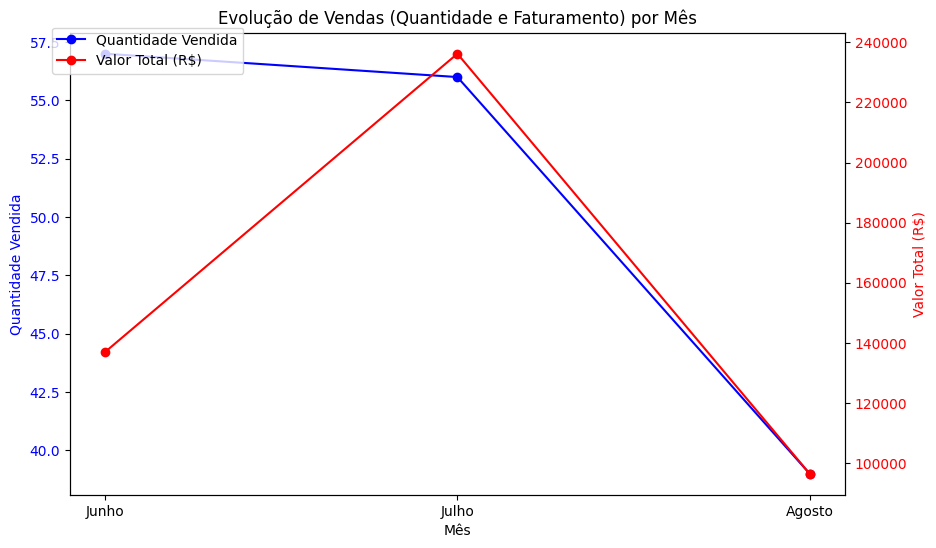

In [ ]:
# Gerar Gráfico de Linha
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Quantidade_Vendida
ax1.plot(df_grouped['Mes'], df_grouped['Quantidade_Vendida'], marker='o', color='b', label='Quantidade Vendida')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Quantidade Vendida', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis for Valor_Total
ax2 = ax1.twinx()
ax2.plot(df_grouped['Mes'], df_grouped['Valor_Total'], marker='o', color='r', label='Valor Total (R$)')
ax2.set_ylabel('Valor Total (R$)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title('Evolução de Vendas (Quantidade e Faturamento) por Mês')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.show()

# Relatório de Inteligência de Vendas

### **KPIs gerais**

Calcular:

Faturamento_total = soma(Valor_Total)

Quantidade_total = soma(Quantidade)

Ticket_medio = Faturamento_total / Quantidade_total

In [ ]:
# Calcualando os KPIs
Faturamento_Total =df['Valor_Total'].sum()
Quantidade_Total = df['Quantidade_Vendida'].sum()
Ticket_Medio = Faturamento_Total/Quantidade_Total

print(f'faturamento Total:{Faturamento_Total:.2f}')
print(f'Quantidade Total:{Quantidade_Total:.2f}')
print(f'Ticket Médio: {Ticket_Medio:.2f}')


faturamento Total:469700.00
Quantidade Total:152.00
Ticket Médio: 3090.13


###**Análise por Produto**

In [ ]:
df_grouped = df.groupby(['Produto'])[['Quantidade_Vendida', "Valor_Total"]].sum().reset_index()
df_grouped = df_grouped.sort_values(by='Valor_Total', ascending=False)
display(df_grouped.head())

,Produto,Quantidade_Vendida,Valor_Total
0,Container,26,234000.0
1,Porta automática,27,135000.0
3,Telha termoacústica,64,83200.0
2,Serviços adicionais,35,17500.0


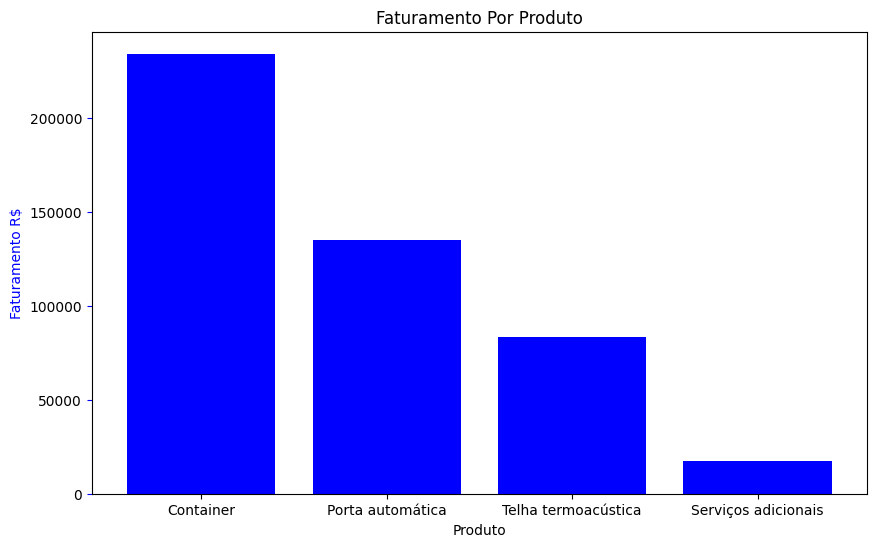

In [ ]:
# Criar grafico de Barras: Produto x Faturamento
fig, ax1= plt.subplots(figsize=(10,6))
ax1.bar(df_grouped['Produto'], df_grouped['Valor_Total'], color='b')
ax1.set_xlabel('Produto')
ax1.set_ylabel('Faturamento R$', color='b')
ax1.tick_params(axis='y', color='b')
plt.title('Faturamento Por Produto')
plt.show()

### **Análise por Canal de Venda**

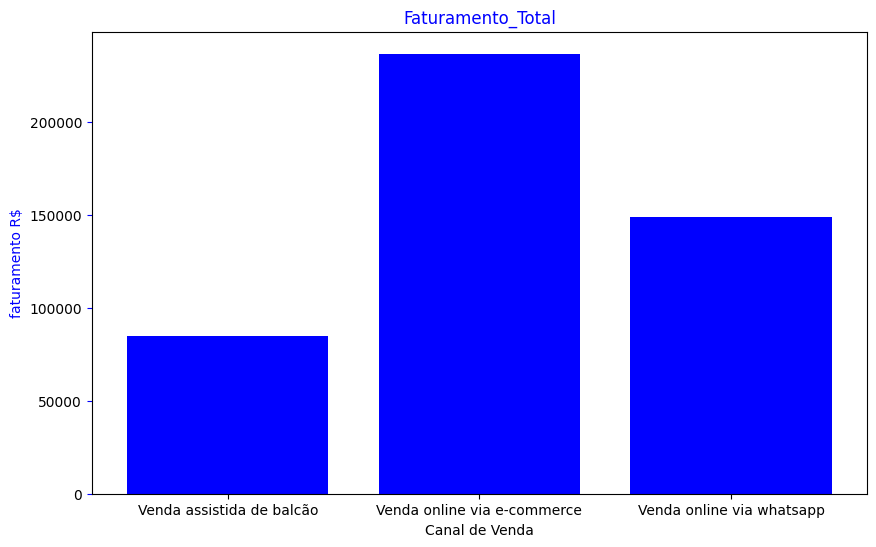

In [ ]:
df_grouped = df.groupby(['Canal_Venda'])[['Quantidade_Vendida', "Valor_Total"]].sum().reset_index()

# Grafico de barras: Canal VS Faturamento
fig, ax1=plt.subplots(figsize=(10,6))
ax1.bar(df_grouped['Canal_Venda'], df_grouped['Valor_Total'], color='b')
ax1.set_xlabel('Canal de Venda')
ax1.set_ylabel('faturamento R$', color='b')
ax1.tick_params(axis='y', color='b')
plt.title('Faturamento Total', color='b')

plt.show()


### **Evolução no Tempo**

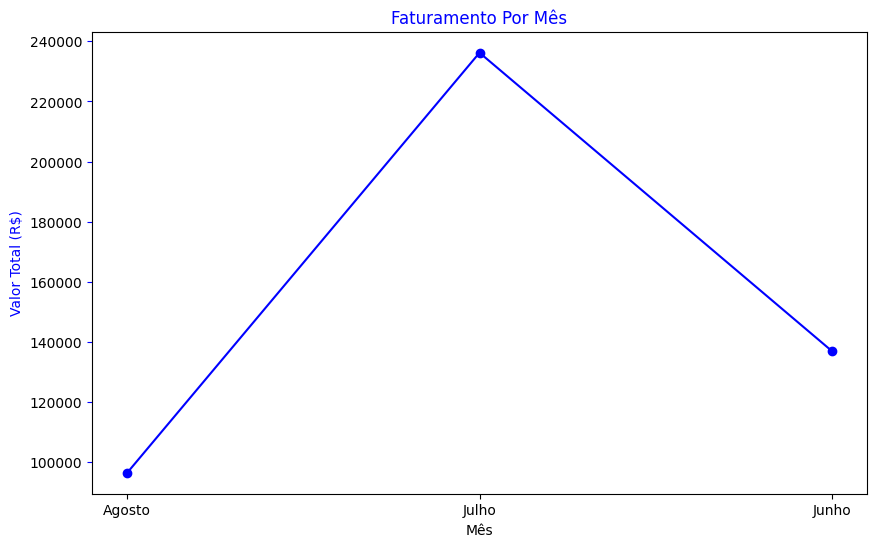

In [ ]:
# Evolução do Faturamento nos meses
df_grouped=df.groupby(['Mes'])[['Quantidade_Vendida', 'Valor_Total']].sum().reset_index()

# Grafico de linha: Mês VS Faturamento
fig, ax1=plt.subplots(figsize=(10,6))
ax1.plot(df_grouped['Mes'], df_grouped['Valor_Total'], marker='o', color='b', label='Valor Total (R$)')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor Total (R$)', color='b')
ax1.tick_params(axis='y', color='b')
plt.title('Faturamento Por Mês', color='b')

plt.show()
